<a href="https://colab.research.google.com/github/chris1982-arch/Advanced-Data-Mining-/blob/main/Data_Processing_Reviewed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pip install -q wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.3 MB/s eta 0:00:00


In [3]:
# Install dependencies into the notebook kernel (uncomment if necessary).
# %pip install -r requirements.txt
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from scipy.signal import butter, sosfiltfilt
from collections import Counter
import json
import importlib.metadata

SEED = 42
rng = np.random.default_rng(SEED)
DATA_DIR = Path('mitdb')
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
CLASSES = ['N', 'S', 'V', 'F']
FS = 360
window_before, window_after = 60, 90
window_size = window_before + window_after
# The interval [peak - 60, peak + 90) includes the annotated sample:
# 60 preceding samples, the center sample and 89 subsequent samples.


# Submission 1 — reviewed ECG data preparation
Run every cell in order. This copy corrects lead selection, training-only weights,
reproducible augmentation and the final split. Outputs from the original notebook
were cleared because they no longer describe this pipeline.

DS2 is processed only to export the required fixed test statistics; it is excluded
from exploratory plots, split selection, class weights and augmentation.
The original notebook already inspected DS2: this cannot be undone. Disclose this
and do not describe the historical workflow as an untouched test set.


In [4]:
DS1 = ['101','106','108','109','112','114','115','116','118','119',
       '122','124','201','203','205','207','208','209','215','220',
       '223','230']

DS2 = ['100','103','105','111','113','117','121','123','200','202',
       '210','212','213','214','219','221','222','228','231','232',
       '233','234']
# The course's standard protocol is record-disjoint, but records 201 and 202
# belong to the same person. Drop 201 from development for strict patient separation.
# Set this to False only to reproduce the exact course record lists, and disclose
# that this alternative is not fully patient-independent.
STRICT_PATIENT_SPLIT = True
ds1_final = [r for r in DS1 if not (STRICT_PATIENT_SPLIT and r == '201')]
ds2_final = DS2.copy()
val_records = ['223', '205', '124', '109']
train_records = [r for r in ds1_final if r not in val_records]
test_records = ds2_final.copy()
all_records = ds1_final + ds2_final
eda_records = ds1_final.copy()
usable_records = all_records.copy()
assert not (set(train_records) & set(val_records))
assert not (set(ds1_final) & set(ds2_final))
def subject_id(record_id):
    return '201_202' if record_id in {'201', '202'} else record_id
if STRICT_PATIENT_SPLIT:
    assert not ({subject_id(r) for r in ds1_final} & {subject_id(r) for r in ds2_final})
print({'train': train_records, 'validation': val_records, 'test': test_records})
# Download only the records used by the fixed protocol; keep raw files local.
wfdb.dl_database('mitdb', dl_dir=str(DATA_DIR), records=all_records)


{'train': ['101', '106', '108', '112', '114', '115', '116', '118', '119', '122', '203', '207', '208', '209', '215', '220', '230'], 'validation': ['223', '205', '124', '109'], 'test': ['100', '103', '105', '111', '113', '117', '121', '123', '200', '202', '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']}
Generating record list for: 101
Generating record list for: 106
Generating record list for: 108
Generating record list for: 109
Generating record list for: 112
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 118
Generating record list for: 119
Generating record list for: 122
Generating record list for: 124
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generating record list for: 215
Generating record list for: 220
Generating record list for: 223
Generating record lis

## 2. Data understanding and 3.2 Lead selection
Select MLII by its name, rather than assuming channel zero. Record 114 has reversed
channels and remains eligible. Records 102/104/107/217 are outside the course DS1/DS2
protocol. Additional exclusion: 201 under the strict patient separation option.


In [5]:
# Headers determine the correct lead index for each record.
lead_rows = []
lead_indices = {}
for rec in all_records:
    header = wfdb.rdheader(str(DATA_DIR / rec))
    if header.fs != FS:
        raise ValueError(f'Unexpected sampling frequency in record {rec}: {header.fs}')
    if 'MLII' not in header.sig_name:
        raise ValueError(f'MLII missing in record {rec}; document an exclusion before continuing.')
    lead_indices[rec] = header.sig_name.index('MLII')
    lead_rows.append({'record': rec, 'channels': header.sig_name,
                      'selected_index': lead_indices[rec], 'fs': header.fs,
                      'duration_seconds': header.sig_len / header.fs})
lead_df = pd.DataFrame(lead_rows)
lead_df.to_csv(RESULTS_DIR / 'lead_selection.csv', index=False)
print(lead_df)


   record    channels  selected_index   fs  duration_seconds
0     101  [MLII, V1]               0  360       1805.555556
1     106  [MLII, V1]               0  360       1805.555556
2     108  [MLII, V1]               0  360       1805.555556
3     109  [MLII, V1]               0  360       1805.555556
4     112  [MLII, V1]               0  360       1805.555556
5     114  [V5, MLII]               1  360       1805.555556
6     115  [MLII, V1]               0  360       1805.555556
7     116  [MLII, V1]               0  360       1805.555556
8     118  [MLII, V1]               0  360       1805.555556
9     119  [MLII, V1]               0  360       1805.555556
10    122  [MLII, V1]               0  360       1805.555556
11    124  [MLII, V4]               0  360       1805.555556
12    203  [MLII, V1]               0  360       1805.555556
13    205  [MLII, V1]               0  360       1805.555556
14    207  [MLII, V1]               0  360       1805.555556
15    208  [MLII, V1]   

In [6]:
import os
import pandas as pd

# AAMI mapping: original MIT-BIH annotation symbol -> final class
aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
}
excluded_symbols = {'/', 'f', 'Q'}  # paced / unclassifiable beats

rows = []
for rec in all_records:
    ann = wfdb.rdann(str(DATA_DIR / rec), 'atr')
    for sample, sym in zip(ann.sample, ann.symbol):
        if sym in aami_map:
            final_class = aami_map[sym]
        elif sym in excluded_symbols:
            final_class = 'EXCLUDED'
        else:
            final_class = 'OTHER'  # unsupported events, rhythm/quality markers or artifacts; audit every symbol
        rows.append({'record': rec, 'sample': sample, 'symbol': sym, 'final_class': final_class})

beats = pd.DataFrame(rows)
print(f"Total annotations: {len(beats)}")
beats.head()

Total annotations: 101685


,record,sample,symbol,final_class
0,101,7,+,OTHER
1,101,83,N,N
2,101,396,N,N
3,101,711,N,N
4,101,1032,N,N


In [7]:
# Audit every excluded symbol; OTHER must not be assumed to contain only rhythm markers.
annotation_audit = beats.groupby(['record', 'symbol', 'final_class']).size().reset_index(name='count')
annotation_audit.to_csv(RESULTS_DIR / 'annotation_audit.csv', index=False)
print(annotation_audit.groupby(['symbol', 'final_class'])['count'].sum())
# All exploratory decisions and figures use development records only.
beats_all = beats.copy()
beats = beats_all[beats_all['record'].isin(eda_records)].copy()
class_counts = beats[beats.final_class.isin(CLASSES)].final_class.value_counts().reindex(CLASSES, fill_value=0)
print(class_counts)


symbol  final_class
!       OTHER            472
"       OTHER            437
+       OTHER           1138
A       S               2516
E       V                106
F       F                801
J       S                 82
L       N               8075
N       N              72921
Q       EXCLUDED          15
R       N               7259
S       S                  2
V       V               6705
[       OTHER              6
]       OTHER              6
a       S                 53
e       N                 16
j       N                219
x       OTHER            156
|       OTHER            131
~       OTHER            569
Name: count, dtype: int64
final_class
N    44231
S      816
V     3590
F      413
Name: count, dtype: int64


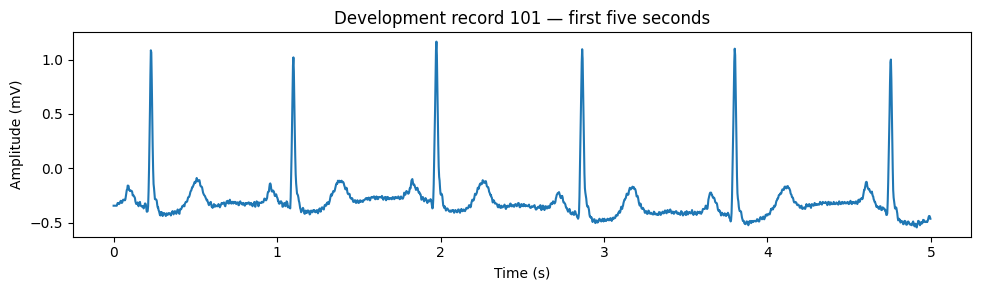

In [8]:
# Show five seconds from development record 101; DS2 is excluded from EDA.
record = wfdb.rdrecord(str(DATA_DIR / '101'))
signal = record.p_signal[:FS * 5, lead_indices['101']]
plt.figure(figsize=(10, 3))
plt.plot(np.arange(len(signal)) / FS, signal)
plt.xlabel('Time (s)'); plt.ylabel('Amplitude (mV)')
plt.title('Development record 101 — first five seconds')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'raw_ecg.png'); plt.show()


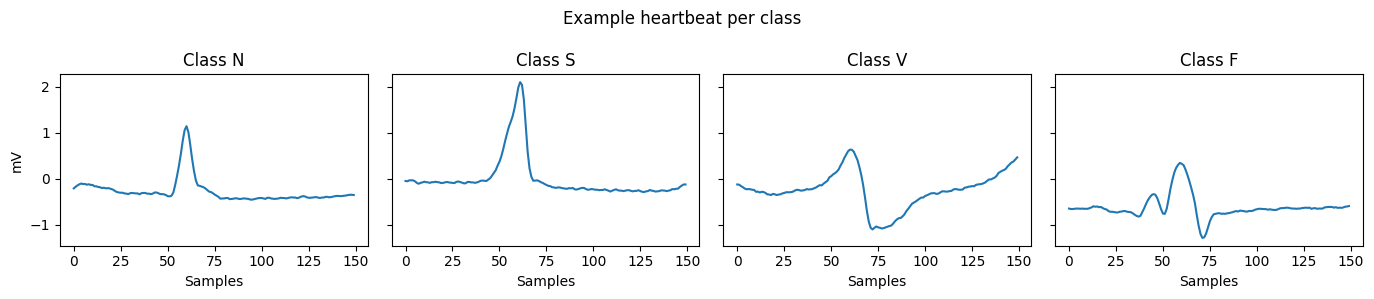

In [9]:
import numpy as np

# Plot one example heartbeat for each class (N, S, V, F)
window_before = 60   # samples before the R-peak (~0.167 s at 360 Hz)
window_after = 90   # samples after the R-peak

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)

for ax, cls in zip(axes, ['N', 'S', 'V', 'F']):
    # pick one example beat of this class
    example = beats[beats['final_class'] == cls].iloc[10]
    rec = wfdb.rdrecord(f"mitdb/{example['record']}")
    center = int(example['sample'])
    beat_signal = rec.p_signal[center - window_before : center + window_after, lead_indices[str(example['record'])]]

    ax.plot(beat_signal)
    ax.set_title(f"Class {cls}")
    ax.set_xlabel("Samples")

axes[0].set_ylabel("mV")
plt.suptitle("Example heartbeat per class")
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_6.png'); plt.show()

In [10]:
# Check minimum distance between consecutive beat annotations, per record
# This tells us whether our 150-sample window risks overlapping the next beat

min_distances = []

for rec in eda_records:
    rec_beats = beats[(beats['record'] == rec) & (beats['final_class'].isin(['N','S','V','F']))]
    samples_sorted = rec_beats['sample'].sort_values().values
    if len(samples_sorted) > 1:
        diffs = np.diff(samples_sorted)
        min_distances.append(diffs.min())

min_distances = np.array(min_distances)
print(f"Smallest gap between two consecutive beats (across all records): {min_distances.min()} samples")
print(f"Number of records with a gap smaller than 150 samples: {(min_distances < 150).sum()} out of {len(min_distances)}")

Smallest gap between two consecutive beats (across all records): 90 samples
Number of records with a gap smaller than 150 samples: 8 out of 21


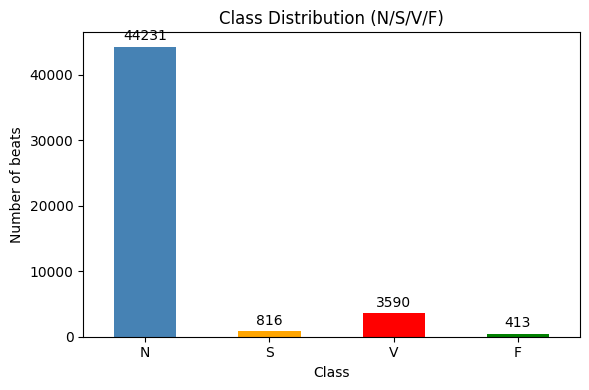

In [11]:
# Class distribution bar chart (Section 2.3 EDA)
class_counts = beats[beats['final_class'].isin(['N', 'S', 'V', 'F'])].groupby('final_class').size()
class_counts = class_counts.reindex(['N', 'S', 'V', 'F'])  # keep consistent order

plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['steelblue', 'orange', 'red', 'green'])
plt.title("Class Distribution (N/S/V/F)")
plt.xlabel("Class")
plt.ylabel("Number of beats")
plt.xticks(rotation=0)

# add exact counts on top of each bar
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 1000, str(v), ha='center')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_8.png'); plt.show()

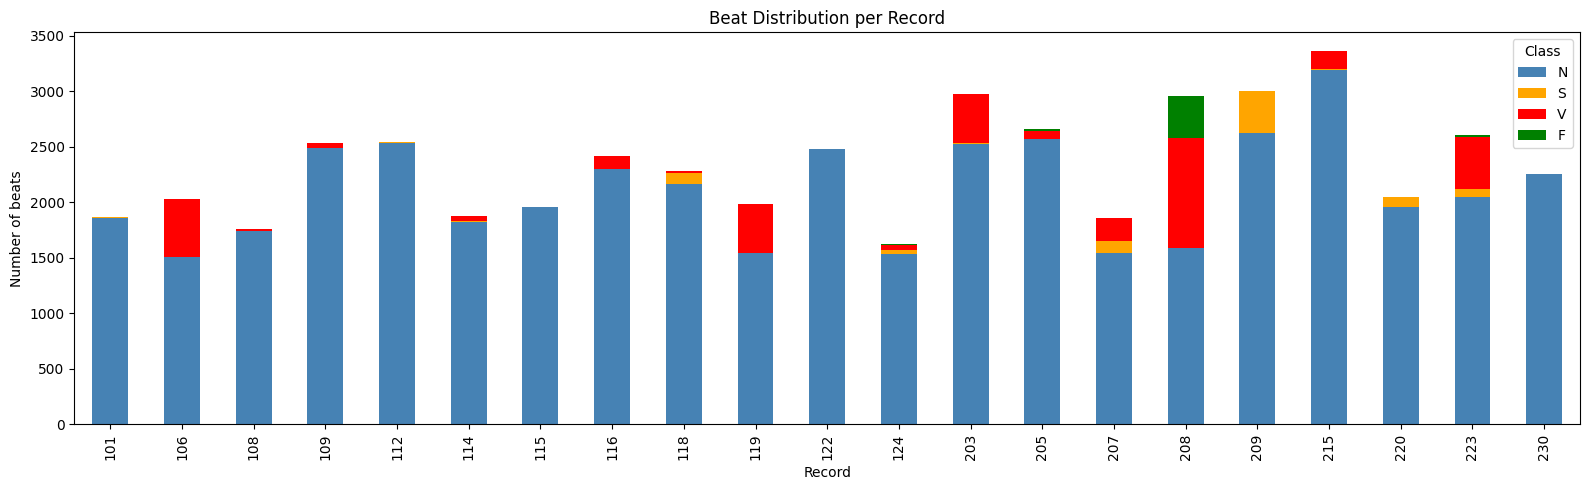

In [ ]:
# Beat distribution per record (Section 2.3 EDA)
beat_df = beats[beats['final_class'].isin(['N', 'S', 'V', 'F'])]
per_record = beat_df.pivot_table(index='record', columns='final_class',
                                   values='sample', aggfunc='count', fill_value=0)
per_record = per_record[['N', 'S', 'V', 'F']]  # consistent column order

per_record.plot(kind='bar', stacked=True, figsize=(16, 5),
                 color=['steelblue', 'orange', 'red', 'green'])
plt.title("Beat Distribution per Record")
plt.xlabel("Record")
plt.ylabel("Number of beats")
plt.legend(title="Class")
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_9.png'); plt.show()

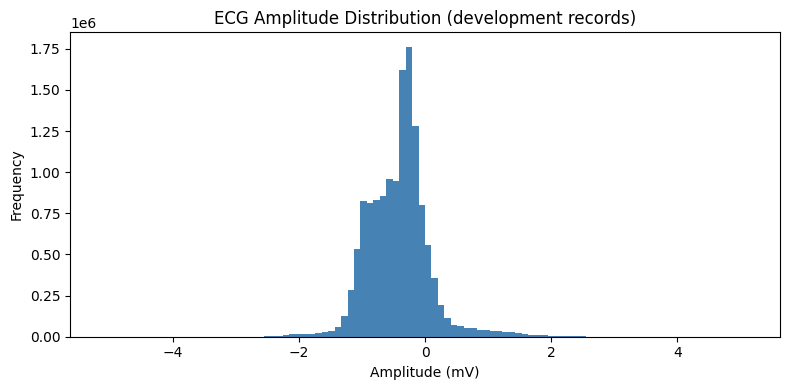

Min amplitude: -5.120 mV
Max amplitude: 5.115 mV
Mean: -0.420 mV, Std: 0.501 mV


In [15]:
all_amplitudes = []

for rec in eda_records:
    r = wfdb.rdrecord(f"mitdb/{rec}")
    all_amplitudes.append(r.p_signal[:, lead_indices[rec]])

all_amplitudes = np.concatenate(all_amplitudes)

plt.figure(figsize=(8, 4))
plt.hist(all_amplitudes, bins=100, color='steelblue')
plt.title("ECG Amplitude Distribution (development records)")
plt.xlabel("Amplitude (mV)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_10.png'); plt.show()

print(f"Min amplitude: {all_amplitudes.min():.3f} mV")
print(f"Max amplitude: {all_amplitudes.max():.3f} mV")
print(f"Mean: {all_amplitudes.mean():.3f} mV, Std: {all_amplitudes.std():.3f} mV")

In [14]:
# Check for missing/NaN values across all records (Section 2.4 Data Quality)
missing_report = []

for rec in eda_records:
    r = wfdb.rdrecord(f"mitdb/{rec}")
    n_nan = np.isnan(r.p_signal).sum()
    missing_report.append({'record': rec, 'nan_count': n_nan, 'total_samples': r.p_signal.size})

missing_df = pd.DataFrame(missing_report)
print(f"Total NaN values across all records: {missing_df['nan_count'].sum()}")
print(f"Records with missing data: {(missing_df['nan_count'] > 0).sum()} out of {len(missing_df)}")

Total NaN values across all records: 0
Records with missing data: 0 out of 21


In [13]:
# Check for extreme amplitude values across all records (Section 2.4 Data Quality)
threshold = 4.0  # mV — values beyond this are considered extreme/suspicious

extreme_report = []

for rec in eda_records:
    r = wfdb.rdrecord(f"mitdb/{rec}")
    sig = r.p_signal[:, lead_indices[rec]]
    n_extreme = (np.abs(sig) > threshold).sum()
    extreme_report.append({'record': rec, 'extreme_count': n_extreme, 'pct': 100 * n_extreme / len(sig)})

extreme_df = pd.DataFrame(extreme_report)
print(f"Total extreme samples (|amplitude| > {threshold} mV): {extreme_df['extreme_count'].sum()}")
print(f"Records with at least one extreme sample: {(extreme_df['extreme_count'] > 0).sum()} out of {len(extreme_df)}")
print("\nTop 5 records with most extreme values:")
print(extreme_df.sort_values('extreme_count', ascending=False).head())

Total extreme samples (|amplitude| > 4.0 mV): 1752
Records with at least one extreme sample: 2 out of 21

Top 5 records with most extreme values:
   record  extreme_count       pct
7     116           1720  0.264615
12    203             32  0.004923
2     108              0  0.000000
1     106              0  0.000000
0     101              0  0.000000


In [12]:
# Check which ECG lead (channel) each record uses (Section 2.4 Data Quality)
lead_report = []

for rec in eda_records:
    r = wfdb.rdrecord(f"mitdb/{rec}")
    lead_report.append({'record': rec, 'channels': r.sig_name})

lead_df = pd.DataFrame(lead_report)
print(lead_df)

# Count how many records have each lead in channel 0
print("\nChannel 0 lead counts:")
print(lead_df['channels'].apply(lambda x: x[0]).value_counts())

   record    channels
0     101  [MLII, V1]
1     106  [MLII, V1]
2     108  [MLII, V1]
3     109  [MLII, V1]
4     112  [MLII, V1]
5     114  [V5, MLII]
6     115  [MLII, V1]
7     116  [MLII, V1]
8     118  [MLII, V1]
9     119  [MLII, V1]
10    122  [MLII, V1]
11    124  [MLII, V4]
12    203  [MLII, V1]
13    205  [MLII, V1]
14    207  [MLII, V1]
15    208  [MLII, V1]
16    209  [MLII, V1]
17    215  [MLII, V1]
18    220  [MLII, V1]
19    223  [MLII, V1]
20    230  [MLII, V1]

Channel 0 lead counts:
channels
MLII    20
V5       1
Name: count, dtype: int64


### 2.5 Leakage analysis
Nearby beats share patient morphology, lead configuration, recording conditions and
sometimes overlapping samples. Random beat splitting would expose these features
in both training and evaluation. Entire records are assigned before training;
201 is excluded because its subject also appears as 202 in DS2. Development-only
EDA and training-only weights prevent test-derived decisions. Fixed per-beat
normalization uses only the current input. DS2 summary statistics are a reporting
artifact, not a source for tuning.

Overlapping windows inside one split are correlated observations, but are not
cross-split leakage. A 150-sample window lasts 0.417 s and may omit P/T morphology;
its suitability must be evaluated on DS1 in Submission 2.


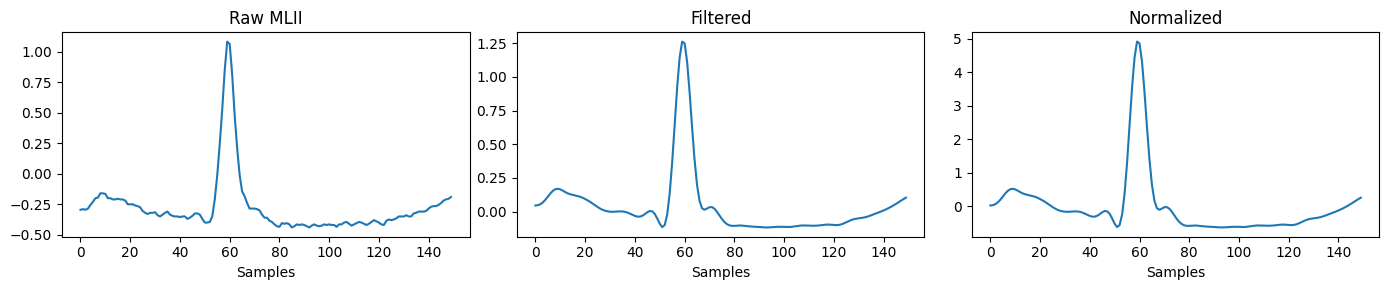

In [16]:
# Use second-order sections for stable low-frequency Butterworth filtering.
# This is an offline, non-causal pipeline; streaming hardware needs a separately
# validated causal filter and an R-peak detector. Annotation-centered results
# evaluate classification with reference beat timing, not a full ECG detector.
def bandpass_filter(signal, fs=FS, lowcut=0.5, highcut=40, order=4):
    sos = butter(order, [lowcut, highcut], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, signal)

X_filtered, y_filtered, record_ids_filtered, centers = [], [], [], []
rejections = []
quality_rows = []
raw_example = None
for rec in usable_records:
    r = wfdb.rdrecord(str(DATA_DIR / rec))
    raw_signal = r.p_signal[:, lead_indices[rec]]
    # Never let invalid values silently propagate through the whole filter.
    if not np.isfinite(raw_signal).all():
        raise ValueError(f'Non-finite ECG samples in {rec}; define a documented repair policy.')
    quality_rows.append({'record': rec, 'selected_lead': 'MLII',
                         'min_mv': float(raw_signal.min()), 'max_mv': float(raw_signal.max()),
                         'extreme_count': int((np.abs(raw_signal) > 4).sum()),
                         'nonfinite_all_channels': int((~np.isfinite(r.p_signal)).sum())})
    filtered_signal = bandpass_filter(raw_signal)
    selected = beats_all[(beats_all.record == rec) & beats_all.final_class.isin(CLASSES)]
    for row in selected.itertuples(index=False):
        center = int(row.sample)
        start, end = center - window_before, center + window_after
        if start < 0 or end > len(filtered_signal):
            rejections.append({'record': rec, 'sample': center, 'class': row.final_class, 'reason': 'boundary'})
            continue
        segment = filtered_signal[start:end]
        if not np.isfinite(segment).all() or segment.std() < 1e-8:
            rejections.append({'record': rec, 'sample': center, 'class': row.final_class, 'reason': 'invalid_or_flat'})
            continue
        if raw_example is None:
            raw_example = raw_signal[start:end].copy()
        X_filtered.append(segment)
        y_filtered.append(row.final_class)
        record_ids_filtered.append(rec)
        centers.append(center)
X_filtered = np.asarray(X_filtered, dtype=np.float32)
y_final = np.asarray(y_filtered)
record_ids_final = np.asarray(record_ids_filtered)
centers = np.asarray(centers, dtype=np.int64)
# Normalize independently; no population statistics are fitted on validation/test.
X_final = ((X_filtered - X_filtered.mean(axis=1, keepdims=True)) /
           np.maximum(X_filtered.std(axis=1, keepdims=True), 1e-8)).astype(np.float32)
assert X_final.shape[1] == window_size and np.isfinite(X_final).all()
pd.DataFrame(rejections, columns=['record', 'sample', 'class', 'reason']).to_csv(RESULTS_DIR / 'rejections.csv', index=False)
pd.DataFrame(quality_rows).to_csv(RESULTS_DIR / 'quality.csv', index=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, values, title in zip(axes, [raw_example, X_filtered[0], X_final[0]], ['Raw MLII', 'Filtered', 'Normalized']):
    ax.plot(values); ax.set_title(title); ax.set_xlabel('Samples')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'preprocessing.png'); plt.show()


In [17]:
# Assign each retained beat to exactly one predeclared record split.
def class_dist(labels, name, records):
    counts = pd.Series(labels).value_counts().reindex(CLASSES, fill_value=0).astype(int)
    counts['Total'] = len(labels)
    counts['Records'] = len(records)
    counts['Subjects'] = len({subject_id(r) for r in records})
    counts.name = name
    return counts
split_rows = []
for split, records in [('Train', train_records), ('Validation', val_records), ('Test', test_records)]:
    mask = np.isin(record_ids_final, records)
    values, labels = X_final[mask], y_final[mask]
    globals()['X_' + {'Train': 'train', 'Validation': 'val', 'Test': 'test'}[split]] = values
    globals()['y_' + {'Train': 'train', 'Validation': 'val', 'Test': 'test'}[split]] = labels
    np.savez_compressed(RESULTS_DIR / (split.lower() + '.npz'), X=values, y=labels,
                        record_ids=record_ids_final[mask], samples=centers[mask])
    split_rows.append(class_dist(labels, split, records))
table_3_8 = pd.DataFrame(split_rows)
table_3_8.to_csv(RESULTS_DIR / 'split_statistics.csv', index_label='Split')
print(table_3_8)
assert len(X_train) + len(X_val) + len(X_test) == len(X_final)
assert all((pd.Series(y_train).value_counts().reindex(CLASSES, fill_value=0) > 0))
# Compute loss weights only AFTER splitting and only from training labels.
train_counts = Counter(y_train)
class_weights = {cls: len(y_train) / (len(CLASSES) * train_counts[cls]) for cls in CLASSES}
(RESULTS_DIR / 'class_weights.json').write_text(json.dumps(class_weights, indent=2))
print('Training-only class weights:', class_weights)


                N     S     V    F  Total  Records  Subjects
Train       35582   709  2961  380  39632       17        17
Validation   8643   107   629   32   9411        4         4
Test        44249  1837  3220  388  49694       22        22
Training-only class weights: {'N': 0.27845539879714465, 'S': 13.974612129760226, 'V': 3.3461668355285377, 'F': 26.073684210526316}


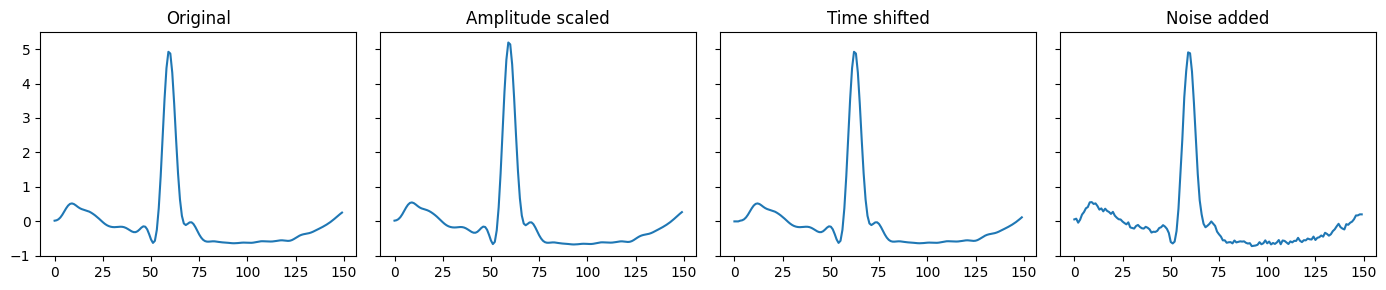

In [18]:
# 3.7 Data Augmentation — define augmentation functions (applied ONLY to training data, later)

def augment_amplitude_scale(signal, scale_range=(0.9, 1.1)):
    """Randomly scale the amplitude of the beat."""
    scale = rng.uniform(*scale_range)
    return signal * scale

def augment_time_shift(signal, max_shift=10):
    """Randomly shift the beat left/right by a few samples (zero-padded, not wrapped)."""
    shift = rng.integers(-max_shift, max_shift + 1)
    shifted = np.zeros_like(signal)
    if shift > 0:
        shifted[shift:] = signal[:-shift]
    elif shift < 0:
        shifted[:shift] = signal[-shift:]
    else:
        shifted = signal.copy()
    return shifted

def augment_add_noise(signal, noise_std=0.05):
    """Add small Gaussian noise to simulate sensor/measurement noise."""
    noise = rng.normal(0, noise_std, size=signal.shape)
    return signal + noise

# Visual demonstration on one example beat
example_beat = X_train[0]

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
axes[0].plot(example_beat); axes[0].set_title("Original")
axes[1].plot(augment_amplitude_scale(example_beat)); axes[1].set_title("Amplitude scaled")
axes[2].plot(augment_time_shift(example_beat)); axes[2].set_title("Time shifted")
axes[3].plot(augment_add_noise(example_beat)); axes[3].set_title("Noise added")
plt.tight_layout()
plt.show()
# These are demonstrations only; validation and test arrays are never augmented.


### Noisy ECG examples and data quality
Gaussian augmentation is not a substitute for the MIT-BIH Noise Stress Test
Database. The following examples use its baseline wander, muscle artifact and
electrode motion signals on development ECG only. They are illustrative EDA,
not model robustness results. Extreme amplitude alone does not identify motion
artifact; plots and quality annotations provide evidence for interpretation.


Generating record list for: bw
Generating record list for: ma
Generating record list for: em
Generating list of all files for: bw
Generating list of all files for: ma
Generating list of all files for: em
Created local base download directory: nstdb
Finished downloading files


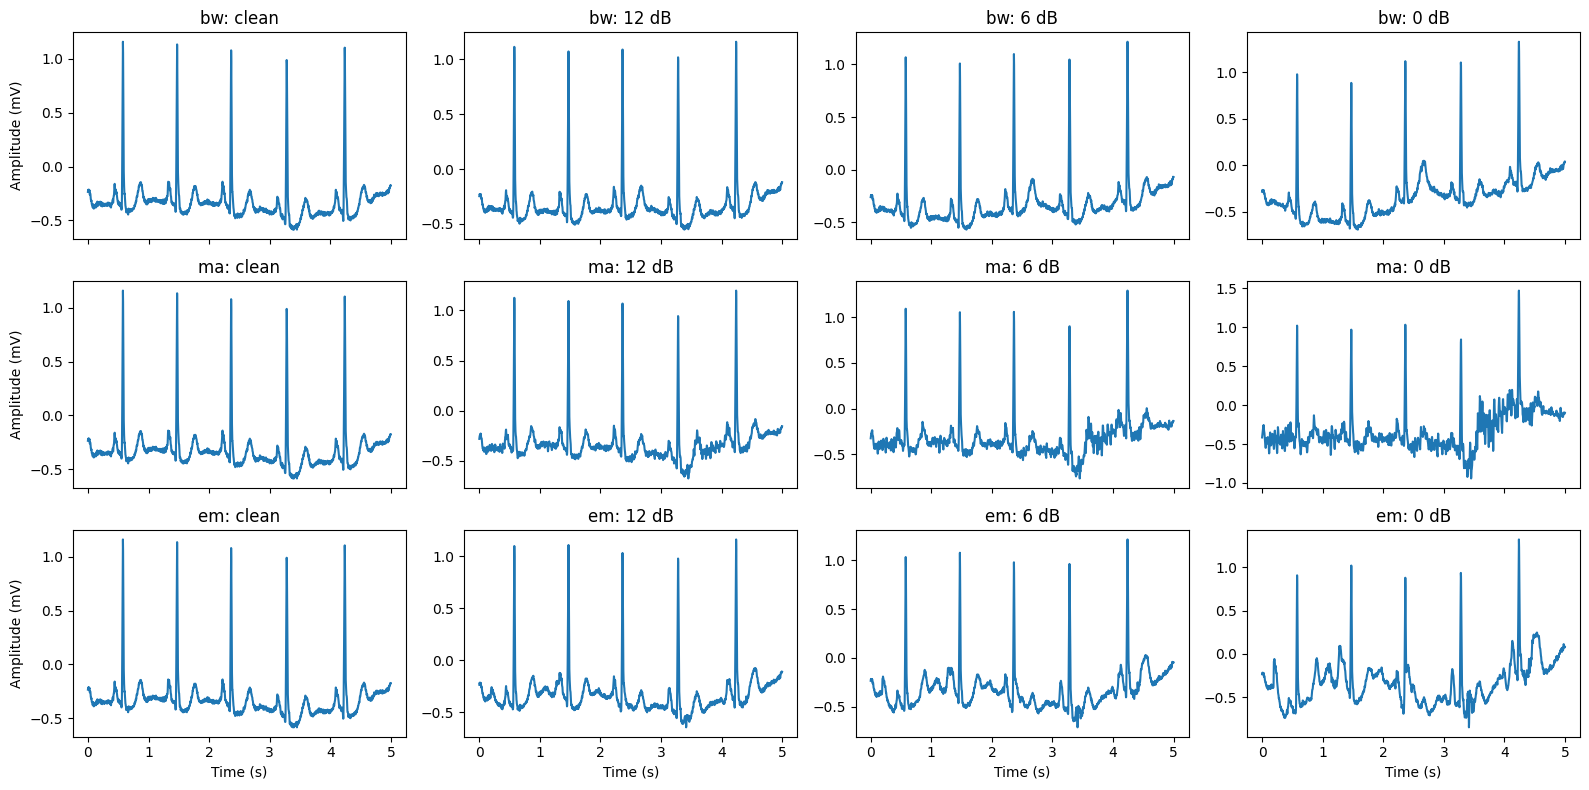

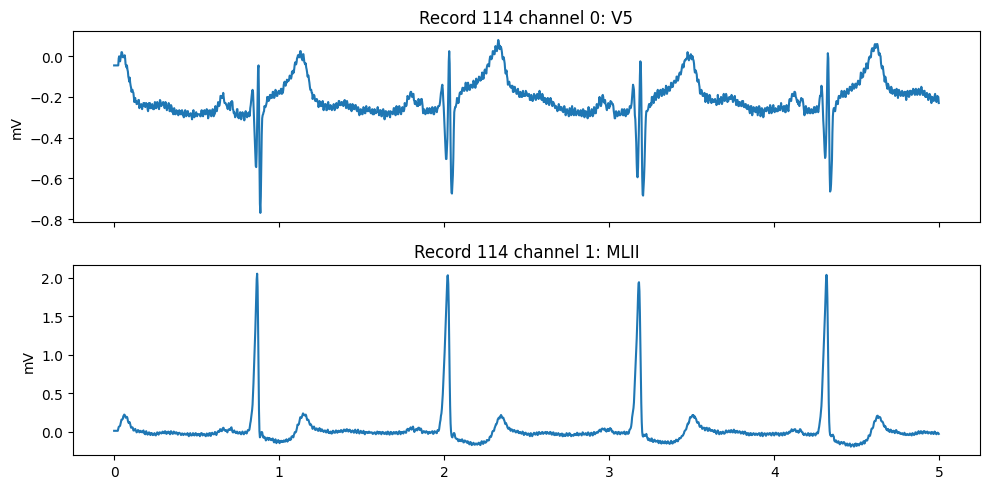

In [19]:
# Download real noise records and illustrate fixed SNR conditions before preprocessing.
noise_dir = Path('nstdb')
wfdb.dl_database('nstdb', dl_dir=str(noise_dir), records=['bw', 'ma', 'em'])
clean_record = wfdb.rdrecord(str(DATA_DIR / '101'))
clean = clean_record.p_signal[FS * 60:FS * 65, lead_indices['101']]
clean_centered = clean - clean.mean()
signal_power = np.mean(clean_centered ** 2)
fig, axes = plt.subplots(3, 4, figsize=(16, 8), sharex=True)
for row, kind in enumerate(['bw', 'ma', 'em']):
    noise = wfdb.rdrecord(str(noise_dir / kind)).p_signal[:len(clean), 0]
    noise = noise - noise.mean()
    assert np.isfinite(noise).all() and np.mean(noise ** 2) > 0
    axes[row, 0].plot(np.arange(len(clean)) / FS, clean)
    axes[row, 0].set_title(f'{kind}: clean')
    for col, snr_db in enumerate([12, 6, 0], start=1):
        scaled_noise = noise * np.sqrt(signal_power / (np.mean(noise ** 2) * 10 ** (snr_db / 10)))
        noisy = clean + scaled_noise
        axes[row, col].plot(np.arange(len(clean)) / FS, noisy)
        axes[row, col].set_title(f'{kind}: {snr_db} dB')
    axes[row, 0].set_ylabel('Amplitude (mV)')
for ax in axes[-1]: ax.set_xlabel('Time (s)')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'noise_examples.png'); plt.show()
# Compare both leads on a development recording, including the reversed record 114.
r114 = wfdb.rdrecord(str(DATA_DIR / '114'))
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for idx, ax in enumerate(axes):
    ax.plot(np.arange(FS * 5) / FS, r114.p_signal[:FS * 5, idx])
    ax.set_title(f'Record 114 channel {idx}: {r114.sig_name[idx]}'); ax.set_ylabel('mV')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'channel_comparison.png'); plt.show()


In [20]:
# Save actual runtime versions and fixed preprocessing decisions, not guessed versions.
versions = {'Python': sys.version}
for package in ['wfdb', 'numpy', 'pandas', 'scipy', 'matplotlib']:
    versions[package] = importlib.metadata.version(package)
manifest = {'seed': SEED, 'versions': versions, 'sampling_frequency': FS,
            'window_before': window_before, 'window_after_exclusive': window_after,
            'input_length': window_size, 'dtype': 'float32',
            'filter': {'order': 4, 'low_hz': 0.5, 'high_hz': 40, 'implementation': 'sosfiltfilt (offline)'},
            'normalization': 'per-beat z-score', 'strict_patient_split': STRICT_PATIENT_SPLIT,
            'splits': {'train': train_records, 'validation': val_records, 'test': test_records},
            'subject_exception': '201/202 are the same subject; 201 omitted in strict mode'}
(RESULTS_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))


{
  "seed": 42,
  "versions": {
    "Python": "3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]",
    "wfdb": "4.3.1",
    "numpy": "2.1.3",
    "pandas": "2.2.3",
    "scipy": "1.16.3",
    "matplotlib": "3.10.0"
  },
  "sampling_frequency": 360,
  "window_before": 60,
  "window_after_exclusive": 90,
  "input_length": 150,
  "dtype": "float32",
  "filter": {
    "order": 4,
    "low_hz": 0.5,
    "high_hz": 40,
    "implementation": "sosfiltfilt (offline)"
  },
  "normalization": "per-beat z-score",
  "strict_patient_split": true,
  "splits": {
    "train": [
      "101",
      "106",
      "108",
      "112",
      "114",
      "115",
      "116",
      "118",
      "119",
      "122",
      "203",
      "207",
      "208",
      "209",
      "215",
      "220",
      "230"
    ],
    "validation": [
      "223",
      "205",
      "124",
      "109"
    ],
    "test": [
      "100",
      "103",
      "105",
      "111",
      "113",
      "117",
      "121",
      "123",
      "2

In [21]:
# Final checks: input validity, labels, split independence and saved files.
from pathlib import Path
from collections import Counter
import json
import numpy as np
import pandas as pd

splits = {
    "Train": (X_train, y_train, train_records),
    "Validation": (X_val, y_val, val_records),
    "Test": (X_test, y_test, test_records),
}

subject_sets = {}

for name, (X_split, y_split, records) in splits.items():
    # Each input must be a finite, normalized 150-sample window.
    assert X_split.shape == (len(y_split), window_size), \
        f"{name}: incorrect input shape"
    assert X_split.dtype == np.float32, f"{name}: incorrect dtype"
    assert np.isfinite(X_split).all(), f"{name}: NaN/Inf values found"
    assert np.allclose(X_split.mean(axis=1), 0, atol=1e-5), \
        f"{name}: normalization mean check failed"
    assert np.allclose(X_split.std(axis=1), 1, atol=1e-5), \
        f"{name}: normalization standard deviation check failed"

    # All four required classes must be represented.
    assert set(y_split.tolist()) == set(CLASSES), \
        f"{name}: missing or unexpected labels"

    # Every declared record must contribute retained beats.
    mask = np.isin(record_ids_final, records)
    assert set(record_ids_final[mask].tolist()) == set(records), \
        f"{name}: record membership mismatch"
    assert np.array_equal(X_split, X_final[mask])
    assert np.array_equal(y_split, y_final[mask])

    subject_sets[name] = {subject_id(r) for r in records}

    # Saved arrays must match the arrays currently in memory.
    file_path = RESULTS_DIR / f"{name.lower()}.npz"
    assert file_path.exists(), f"Missing file: {file_path}"
    with np.load(file_path, allow_pickle=False) as saved:
        assert np.array_equal(saved["X"], X_split)
        assert np.array_equal(saved["y"], y_split)
        assert np.array_equal(saved["record_ids"], record_ids_final[mask])
        assert np.array_equal(saved["samples"], centers[mask])

    print(f"{name}: PASS — {len(y_split):,} beats")

# No record may appear in more than one split.
names = list(splits)
for i, first in enumerate(names):
    for second in names[i + 1:]:
        assert set(splits[first][2]).isdisjoint(splits[second][2]), \
            f"Record leakage: {first} / {second}"

        # Strict mode also requires different patients across splits.
        if STRICT_PATIENT_SPLIT:
            assert subject_sets[first].isdisjoint(subject_sets[second]), \
                f"Patient leakage: {first} / {second}"

assert sum(len(values[1]) for values in splits.values()) == len(y_final), \
    "Some beats are missing from the splits"

# Loss weights must depend only on training labels.
training_counts = Counter(y_train)
saved_weights = json.loads(
    (RESULTS_DIR / "class_weights.json").read_text()
)
for cls in CLASSES:
    expected = len(y_train) / (len(CLASSES) * training_counts[cls])
    assert np.isclose(class_weights[cls], expected)
    assert np.isclose(saved_weights[cls], expected)

# Exported statistics must match the actual split labels.
statistics = pd.read_csv(
    RESULTS_DIR / "split_statistics.csv", index_col="Split"
)
for name, (_, labels, records) in splits.items():
    counts = Counter(labels)
    for cls in CLASSES:
        assert statistics.loc[name, cls] == counts[cls]
    assert statistics.loc[name, "Total"] == len(labels)
    assert statistics.loc[name, "Records"] == len(records)
    assert statistics.loc[name, "Subjects"] == len(subject_sets[name])

print("\nAll final checks passed.")

Train: PASS — 39,632 beats
Validation: PASS — 9,411 beats
Test: PASS — 49,694 beats

All final checks passed.
